# Assignment 1: Feature Extraction and Deep Learning for Images
## Section 4: Semantic Segmentation

### Prasanna Paithankar (21CS30065)

4th February 2026

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### (a) Dataset Preparation

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root, split, transform=None, target_transform=None):
        self.base_dataset = OxfordIIITPet(
            root=root, split=split, target_types="segmentation", download=True
        )
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            mask = self.target_transform(mask)
            mask = (mask * 255).long() - 1
            mask = torch.clamp(mask, 0, 2)

        return image, mask.squeeze(0)


img_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

mask_transform = transforms.Compose(
    [
        transforms.Resize(
            (128, 128), interpolation=transforms.InterpolationMode.NEAREST
        ),
        transforms.ToTensor(),
    ]
)

100%|██████████| 792M/792M [00:28<00:00, 27.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


Visualizing Dataset Samples...


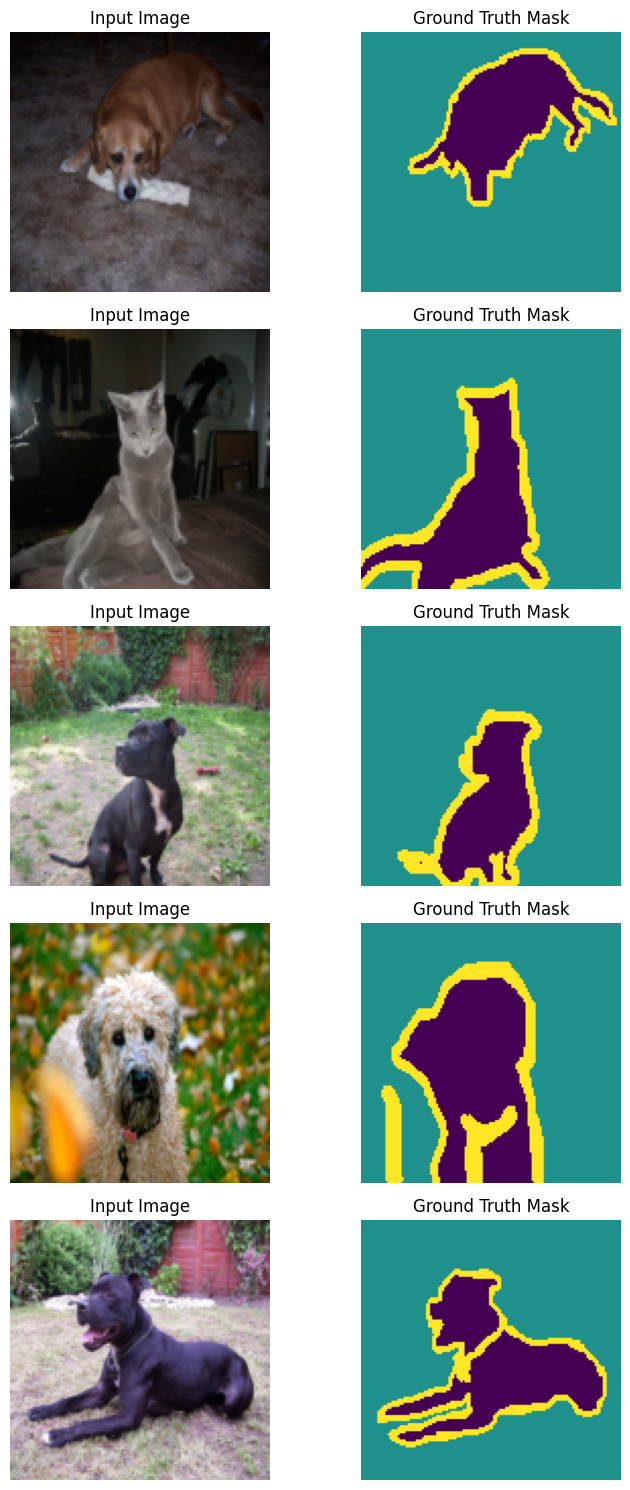

In [ ]:
train_data = PetDataset(
    root="./pet_data",
    split="trainval",
    transform=img_transform,
    target_transform=mask_transform,
)
test_data = PetDataset(
    root="./pet_data",
    split="test",
    transform=img_transform,
    target_transform=mask_transform,
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)


def visualize_dataset(dataset, num_samples=5):
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 3))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]

        # Denormalize for visualization
        img_show = img.permute(1, 2, 0).numpy()
        img_show = img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_show = np.clip(img_show, 0, 1)

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.numpy(), cmap="viridis")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


print("Visualizing Dataset Samples...")
visualize_dataset(train_data)

### (b) U-Net Architecture Implementation

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, use_skip=True):
        super(UNet, self).__init__()
        self.use_skip = use_skip

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024 if use_skip else 512, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512 if use_skip else 256, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256 if use_skip else 128, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128 if use_skip else 64, 64)

        # Final 1x1 Conv
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        # Decoder
        d4 = self.upconv4(b)
        if self.use_skip:
            d4 = torch.cat((e4, d4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        if self.use_skip:
            d3 = torch.cat((e3, d3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        if self.use_skip:
            d2 = torch.cat((e2, d2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        if self.use_skip:
            d1 = torch.cat((e1, d1), dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

In [ ]:
def calculate_metrics(preds, targets, num_classes=3):
    preds = torch.argmax(preds, dim=1)

    # Pixel Accuracy
    correct = (preds == targets).float()
    pixel_acc = correct.sum() / correct.numel()

    # mIoU
    iou_list = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = targets == cls

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            iou_list.append(float("nan"))
        else:
            iou_list.append(intersection / union)

    valid_ious = [x for x in iou_list if not torch.isnan(torch.tensor(x))]
    miou = sum(valid_ious) / len(valid_ious) if valid_ious else 0.0

    return pixel_acc.item(), miou


def train_model(model, train_loader, test_loader, epochs=10, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []
    val_losses = []

    print(f"\nTraining {name}...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0
        total_acc = 0
        total_miou = 0

        with torch.no_grad():
            for images, masks in test_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

                acc, miou = calculate_metrics(outputs, masks)
                total_acc += acc
                total_miou += miou

        avg_val_loss = running_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        avg_acc = total_acc / len(test_loader)
        avg_miou = total_miou / len(test_loader)

        print(
            f"Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {avg_acc:.4f} | mIoU: {avg_miou:.4f}"
        )

    return train_losses, val_losses, avg_acc, avg_miou

### (c) Training and Quantitative Evaluation

In [ ]:
# Train Standard U-Net
unet_standard = UNet(use_skip=True).to(device)
train_loss_std, val_loss_std, acc_std, miou_std = train_model(
    unet_standard, train_loader, test_loader, epochs=10, name="Standard U-Net"
)

# Train No-Skip U-Net
unet_noskip = UNet(use_skip=False).to(device)
train_loss_noskip, val_loss_noskip, acc_noskip, miou_noskip = train_model(
    unet_noskip, train_loader, test_loader, epochs=10, name="No-Skip U-Net"
)

torch.save(unet_standard.state_dict(), "unet_standard.pth")
torch.save(unet_noskip.state_dict(), "unet_noskip.pth")


Training Standard U-Net...


/tmp/ipython-input-3562278905.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_ious = [x for x in iou_list if not torch.isnan(torch.tensor(x))]


Epoch 1/10 | Train Loss: 0.6543 | Val Loss: 0.5881 | Acc: 0.7619 | mIoU: 0.5048
Epoch 2/10 | Train Loss: 0.5227 | Val Loss: 0.4771 | Acc: 0.8148 | mIoU: 0.5856
Epoch 3/10 | Train Loss: 0.4598 | Val Loss: 0.4356 | Acc: 0.8358 | mIoU: 0.6153
Epoch 4/10 | Train Loss: 0.4113 | Val Loss: 0.4094 | Acc: 0.8467 | mIoU: 0.6270
Epoch 5/10 | Train Loss: 0.3769 | Val Loss: 0.3639 | Acc: 0.8613 | mIoU: 0.6565
Epoch 6/10 | Train Loss: 0.3467 | Val Loss: 0.3370 | Acc: 0.8711 | mIoU: 0.6746
Epoch 7/10 | Train Loss: 0.3284 | Val Loss: 0.3156 | Acc: 0.8781 | mIoU: 0.6895
Epoch 8/10 | Train Loss: 0.3113 | Val Loss: 0.3190 | Acc: 0.8771 | mIoU: 0.6885
Epoch 9/10 | Train Loss: 0.2965 | Val Loss: 0.3249 | Acc: 0.8755 | mIoU: 0.6773
Epoch 10/10 | Train Loss: 0.2903 | Val Loss: 0.3040 | Acc: 0.8846 | mIoU: 0.7054

Training No-Skip U-Net...
Epoch 1/10 | Train Loss: 0.7327 | Val Loss: 0.7506 | Acc: 0.7236 | mIoU: 0.3935
Epoch 2/10 | Train Loss: 0.6413 | Val Loss: 0.6325 | Acc: 0.7603 | mIoU: 0.4364
Epoch 3/10 |

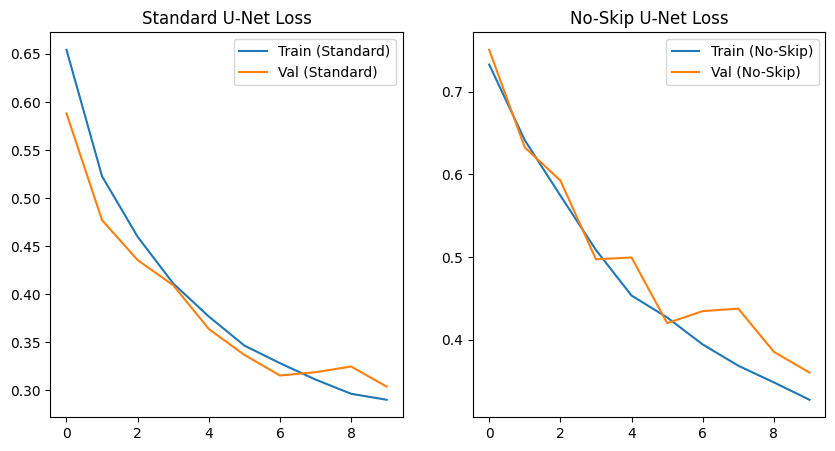


--- Quantitative Comparison ---
Model                | Pixel Acc  | mIoU      
---------------------------------------------
Standard U-Net       | 0.8846     | 0.7054
No-Skip U-Net        | 0.8604     | 0.6416


In [ ]:
def to_cpu(data):
    if hasattr(data, "cpu"):
        return data.cpu().detach().numpy()
    if isinstance(data, list):
        return [x.cpu().detach().numpy() if hasattr(x, "cpu") else x for x in data]
    return data


train_loss_std = to_cpu(train_loss_std)
val_loss_std = to_cpu(val_loss_std)
acc_std = to_cpu(acc_std)
miou_std = to_cpu(miou_std)

train_loss_noskip = to_cpu(train_loss_noskip)
val_loss_noskip = to_cpu(val_loss_noskip)
acc_noskip = to_cpu(acc_noskip)
miou_noskip = to_cpu(miou_noskip)

np.savez(
    "unet_results.npz",
    train_loss_std=train_loss_std,
    val_loss_std=val_loss_std,
    acc_std=acc_std,
    miou_std=miou_std,
    train_loss_noskip=train_loss_noskip,
    val_loss_noskip=val_loss_noskip,
    acc_noskip=acc_noskip,
    miou_noskip=miou_noskip,
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_std, label="Train (Standard)")
plt.plot(val_loss_std, label="Val (Standard)")
plt.title("Standard U-Net Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_noskip, label="Train (No-Skip)")
plt.plot(val_loss_noskip, label="Val (No-Skip)")
plt.title("No-Skip U-Net Loss")
plt.legend()
plt.show()

print("\n--- Quantitative Comparison ---")
print(f"{'Model':<20} | {'Pixel Acc':<10} | {'mIoU':<10}")
print("-" * 45)
print(f"{'Standard U-Net':<20} | {acc_std:.4f}     | {miou_std:.4f}")
print(f"{'No-Skip U-Net':<20} | {acc_noskip:.4f}     | {miou_noskip:.4f}")

### (d) Qualitative Results and Analysis

Good Predictions:


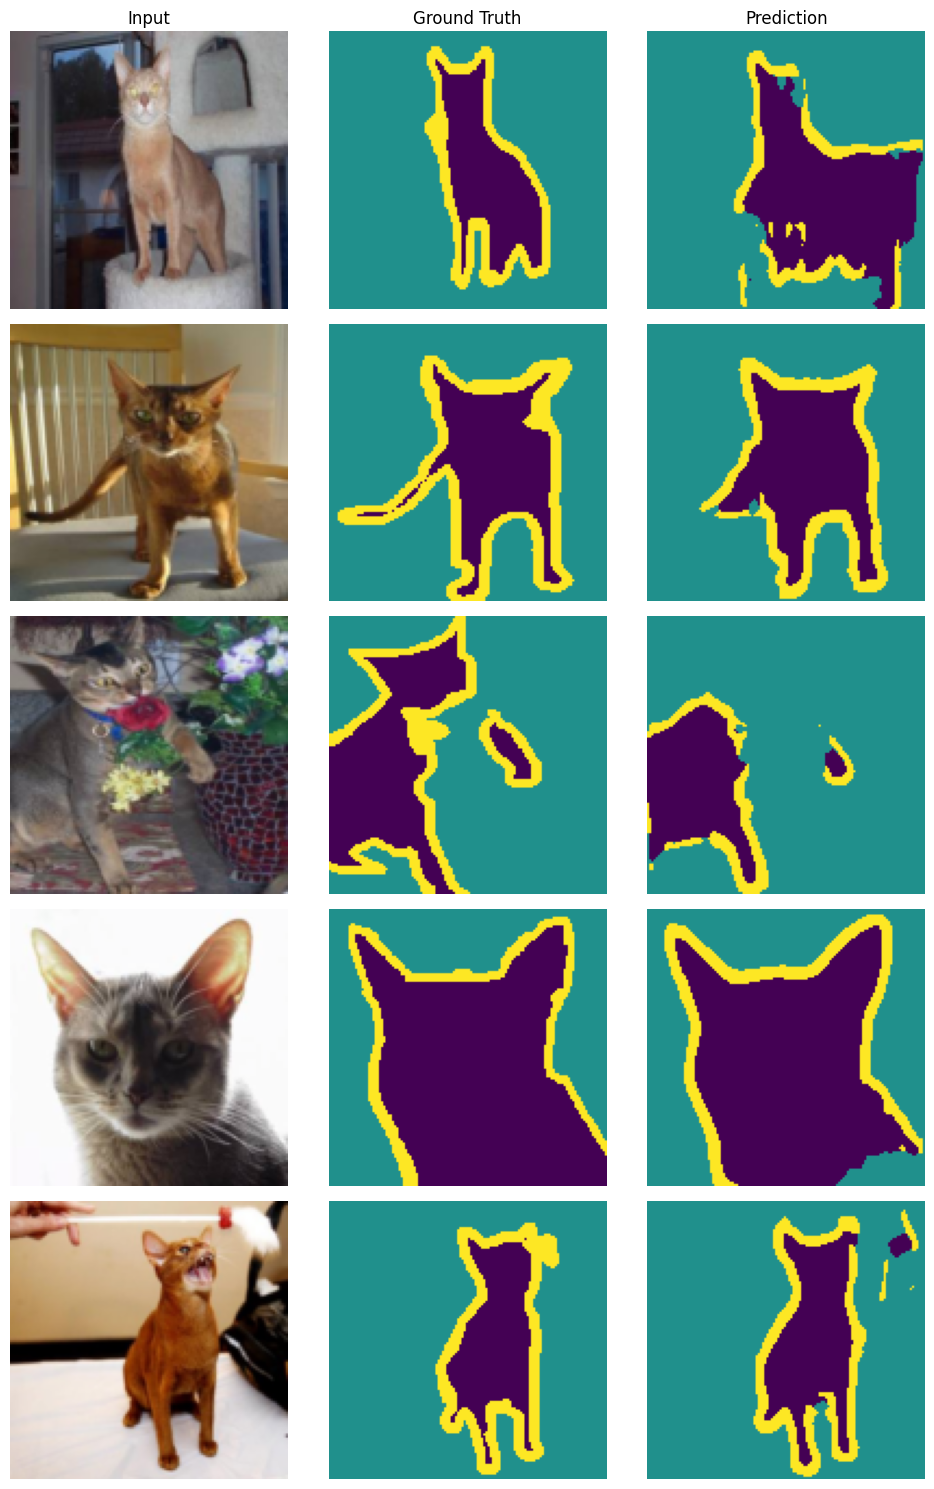


Failure Cases:


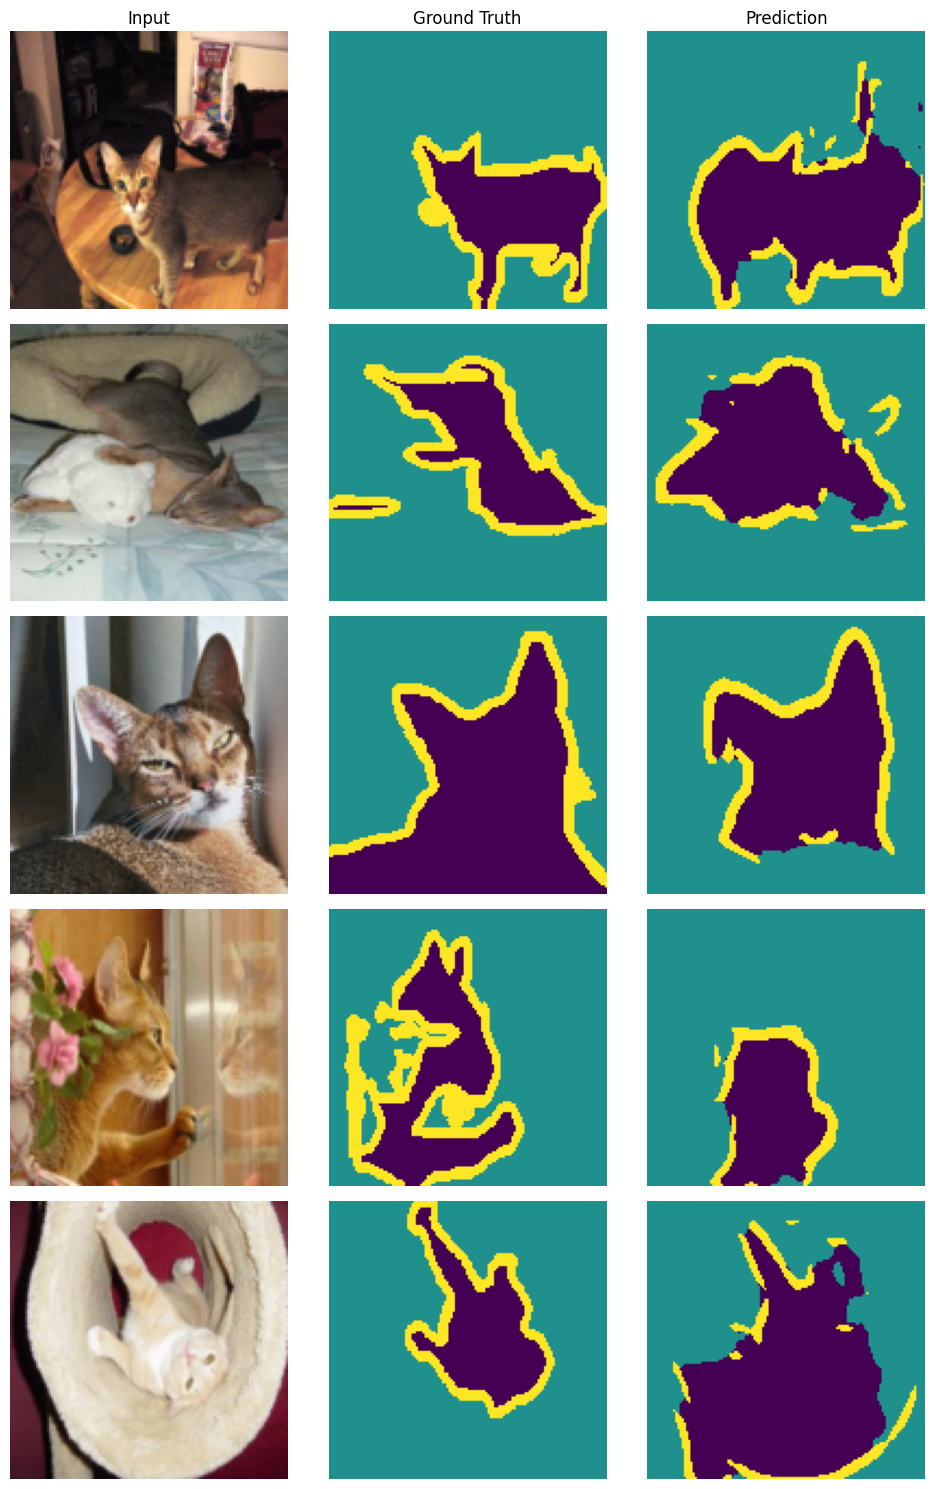

In [ ]:
def visualize_predictions(model, loader, num_samples=5, find_failures=False):
    model.eval()
    count = 0
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 3))
    title_set = False

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.size(0)):
                if count >= num_samples:
                    break

                acc = (preds[i] == masks[i]).float().mean().item()
                if find_failures and acc > 0.8:
                    continue
                if not find_failures and acc < 0.8:
                    continue

                img_show = images[i].cpu().permute(1, 2, 0).numpy()
                img_show = img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
                img_show = np.clip(img_show, 0, 1)

                ax_row = axes[count] if num_samples > 1 else axes

                ax_row[0].imshow(img_show)
                if not title_set:
                    ax_row[0].set_title("Input")

                ax_row[1].imshow(masks[i].cpu().numpy(), cmap="viridis")
                if not title_set:
                    ax_row[1].set_title("Ground Truth")

                ax_row[2].imshow(preds[i].cpu().numpy(), cmap="viridis")
                if not title_set:
                    ax_row[2].set_title("Prediction")

                for ax in ax_row:
                    ax.axis("off")

                title_set = True
                count += 1

            if count >= num_samples:
                break
    plt.tight_layout()
    plt.show()


print("Good Predictions:")
visualize_predictions(unet_standard, test_loader, num_samples=5, find_failures=False)

print("\nFailure Cases:")
visualize_predictions(unet_standard, test_loader, num_samples=5, find_failures=True)

***